**This notebook present llm prediction vs. ground truth results for both molecular glues and PROTACs cohort. Each cohort has 3 independent runs.**

In [4]:
import json
from pathlib import Path

import matplotlib
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

DEEP_TEAL     = "#2D4F54"
ROYAL_PURPLE  = "#7B539E"
SOFT_LAVENDER = "#B8A0D2"
FOREST_GREEN  = "#5A9448"
MUTED_PLUM    = "#9E4A78"
DARK_SLATE    = "#3A3D4A"
HATCH_GRAY    = "#9A9A9A"   

AIME_PALETTE = [DEEP_TEAL, ROYAL_PURPLE, SOFT_LAVENDER,
                FOREST_GREEN, MUTED_PLUM, DARK_SLATE]

AIME_RCPARAMS = {
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         10,
    "axes.facecolor":    "white",
    "axes.edgecolor":    DARK_SLATE,
    "axes.linewidth":    1.0,
    "axes.labelcolor":   DARK_SLATE,
    "axes.labelsize":    10,
    "axes.spines.top":   True,
    "axes.spines.right": True,
    "axes.prop_cycle":   plt.cycler("color", AIME_PALETTE),
    "axes.grid":         False,
    "xtick.color":       DARK_SLATE,
    "ytick.color":       DARK_SLATE,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size":  3.5,
    "ytick.major.size":  3.5,
    "xtick.minor.size":  2.0,
    "ytick.minor.size":  2.0,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "legend.frameon":    False,
    "legend.fontsize":   8.5,
    "legend.labelcolor": DARK_SLATE,
    "figure.facecolor":  "white",
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
    "lines.linewidth":   1.4,
    "lines.markersize":  4.5,
    "hatch.linewidth":   0.6,
    "hatch.color":       HATCH_GRAY,   
}
plt.rcParams.update(AIME_RCPARAMS)
ROOT = Path("/Users/yaochenr/project/molecular_glue_extractor/output/results")
MG_LLM_MECH_DIRS = [ROOT / d for d in ["260504_2355", "260504_2308", "260505_0038"]]
MG_LLM_EXP_DIRS  = [ROOT / d for d in ["260504_2123", "260504_2306", "260505_0037"]]
MG_BL_MECH_PATH  = ROOT / "260326_1614" / "record_based_evaluation_results.json"
MG_BL_EXP_PATH   = ROOT / "260326_1612" / "record_based_evaluation_results.json"
PROTAC_LLM_MECH_DIRS = [ROOT / d for d in ["260424_1729", "260502_1821", "260502_1606"]]
PROTAC_LLM_EXP_DIRS  = [ROOT / d for d in ["260424_1727", "260502_1819", "260502_1600"]]
PROTAC_BL_MECH_PATH  = ROOT / "260424_1732" / "record_based_evaluation_results.json"
PROTAC_BL_EXP_PATH   = ROOT / "260424_1733" / "record_based_evaluation_results.json"

def load_json(path):
    with open(path) as f:
        return json.load(f)

mg_llm_mech_raw = [load_json(d / "record_based_evaluation_results.json")
                   for d in MG_LLM_MECH_DIRS]
mg_llm_exp_raw  = [load_json(d / "record_based_evaluation_results.json")
                   for d in MG_LLM_EXP_DIRS]
mg_bl_mech_raw = load_json(MG_BL_MECH_PATH)
mg_bl_exp_raw  = load_json(MG_BL_EXP_PATH)

protac_llm_mech_raw = [load_json(d / "record_based_evaluation_results.json")
                       for d in PROTAC_LLM_MECH_DIRS]
protac_llm_exp_raw  = [load_json(d / "record_based_evaluation_results.json")
                       for d in PROTAC_LLM_EXP_DIRS]
protac_bl_mech_raw  = load_json(PROTAC_BL_MECH_PATH)
protac_bl_exp_raw   = load_json(PROTAC_BL_EXP_PATH)

print(f"MG     : {len(mg_llm_mech_raw)} replicates (mech + exp) + 2 baselines")
print(f"PROTAC : {len(protac_llm_mech_raw)} replicates (mech + exp) + 2 baselines")

MG     : 3 replicates (mech + exp) + 2 baselines
PROTAC : 3 replicates (mech + exp) + 2 baselines


# Compute metrics


In [5]:
def safe_div(a, b):
    return a / b if b > 0 else float("nan")

def prf(tp, fp, fn):
    p = safe_div(tp, tp + fp)
    r = safe_div(tp, tp + fn)
    f1 = safe_div(2 * p * r, p + r) if (p == p and r == r and (p + r) > 0) else float("nan")
    return p, r, f1

def sd_nonan(vals):
    valid = [v for v in vals if v == v] 
    return np.std(valid, ddof=1) if len(valid) > 1 else float("nan")


def record_prf(part1):
    return (part1["precision_records"], part1["recall_records"], part1["f1_score_records"])

def entry_prf(part2):
    return (part2["precision_entry"], part2["recall_entry"], part2["f1_score_entry"])

mg_mech_arr = np.array([record_prf(r["part1_record_level"]) for r in mg_llm_mech_raw]).T
mg_exp_arr  = np.array([record_prf(r["part1_record_level"]) for r in mg_llm_exp_raw]).T

mg_mech_mean, mg_mech_sd = mg_mech_arr.mean(axis=1), mg_mech_arr.std(axis=1, ddof=1)
mg_exp_mean,  mg_exp_sd  = mg_exp_arr.mean(axis=1),  mg_exp_arr.std(axis=1, ddof=1)

mg_bl_mech = list(record_prf(mg_bl_mech_raw["part1_record_level"]))
mg_bl_exp  = list(record_prf(mg_bl_exp_raw["part1_record_level"]))

protac_mech_arr = np.array([record_prf(r["part1_record_level"]) for r in protac_llm_mech_raw]).T
protac_exp_arr  = np.array([record_prf(r["part1_record_level"]) for r in protac_llm_exp_raw]).T

protac_mech_mean, protac_mech_sd = protac_mech_arr.mean(axis=1), protac_mech_arr.std(axis=1, ddof=1)
protac_exp_mean,  protac_exp_sd  = protac_exp_arr.mean(axis=1),  protac_exp_arr.std(axis=1, ddof=1)

protac_bl_mech = list(record_prf(protac_bl_mech_raw["part1_record_level"]))
protac_bl_exp  = list(record_prf(protac_bl_exp_raw["part1_record_level"]))


FIELDS = ["Cell_Line", "Assay",
          "DC50", "DC50_units", "DC50_h", "Dmax", "Dmax_h", "Dmax_conc"]
CONTEXT_FIELDS = {"Cell_Line", "Assay"}
FIELD_DISPLAY = {
    "Cell_Line":  "Cell Line",
    "Assay":      "Assay",
    "DC50":       "DC50",
    "DC50_units": "DC50 Units",
    "DC50_h":     "DC50 Hours",
    "Dmax":       "Dmax",
    "Dmax_h":     "Dmax Hours",
    "Dmax_conc":  "Dmax Conc.",
}
FIELD_LABELS = [FIELD_DISPLAY[f] for f in FIELDS]

EXP_FIELDS  = ["DC50", "DC50_units", "DC50_h", "Dmax", "Dmax_h", "Dmax_conc"]
MECH_FIELDS = FIELDS

def micro_with_sd(raw_list, fields):
    out = {}
    for field in fields:
        tp_total = fp_total = fn_total = 0
        ps, rs, fs = [], [], []
        for r in raw_list:
            pfm = r["part2_entry_level"]["per_field_metrics"].get(field)
            if pfm is None:
                continue
            tp, fp, fn = pfm["tp"], pfm["fp"], pfm["fn"]
            tp_total += tp; fp_total += fp; fn_total += fn
            p_i, r_i, f1_i = prf(tp, fp, fn)
            ps.append(p_i); rs.append(r_i); fs.append(f1_i)
        p, r, f1 = prf(tp_total, fp_total, fn_total)
        out[field] = {
            "tp": tp_total, "fp": fp_total, "fn": fn_total,
            "p": p,   "p_sd":  sd_nonan(ps),
            "r": r,   "r_sd":  sd_nonan(rs),
            "f1": f1, "f1_sd": sd_nonan(fs),
        }
    return out

mg_field_exp  = micro_with_sd(mg_llm_exp_raw,  EXP_FIELDS)
mg_field_mech = micro_with_sd(mg_llm_mech_raw, MECH_FIELDS)

mg_field_f1     = {f: mg_field_mech[f]["f1"]    for f in MECH_FIELDS}
mg_field_f1_sd  = {f: mg_field_mech[f]["f1_sd"] for f in MECH_FIELDS}

protac_field_exp  = micro_with_sd(protac_llm_exp_raw,  EXP_FIELDS)
protac_field_mech = micro_with_sd(protac_llm_mech_raw, MECH_FIELDS)

protac_field_f1     = {f: protac_field_mech[f]["f1"]    for f in MECH_FIELDS}
protac_field_f1_sd  = {f: protac_field_mech[f]["f1_sd"] for f in MECH_FIELDS}

def f1_from_pfm(pfm, fields=MECH_FIELDS):
    out = {}
    for f in fields:
        if f not in pfm:
            out[f] = float("nan"); continue
        _, _, f1 = prf(pfm[f]["tp"], pfm[f]["fp"], pfm[f]["fn"])
        out[f] = f1
    return out

mg_bl_field_f1     = f1_from_pfm(mg_bl_mech_raw["part2_entry_level"]["per_field_metrics"])
protac_bl_field_f1 = f1_from_pfm(protac_bl_mech_raw["part2_entry_level"]["per_field_metrics"])

def get_metric(raw, section, key):
    return raw[section][key]

PART_KEYS = [
    ("part1_record_level", "precision_records", "P (Part1)"),
    ("part1_record_level", "recall_records",    "R (Part1)"),
    ("part1_record_level", "f1_score_records",  "F1 (Part1)"),
    ("part2_entry_level",  "precision_entry",   "P (Part2)"),
    ("part2_entry_level",  "recall_entry",      "R (Part2)"),
    ("part2_entry_level",  "f1_score_entry",    "F1 (Part2)"),
]

def print_record_table(title, llm_exp_raw, llm_mech_raw, bl_mech_raw, bl_exp_raw, n_label):
    print(title)
    print(f"{'Metric':<14}  {'LLM Exp':>18}  {'LLM Mech':>18}  {'BL Mech':>10}  {'BL Exp':>10}")
    print("=" * 82)
    for section, key, name in PART_KEYS:
        exp_vals  = [get_metric(r, section, key) for r in llm_exp_raw]
        mech_vals = [get_metric(r, section, key) for r in llm_mech_raw]
        exp_m,  exp_s  = np.mean(exp_vals),  np.std(exp_vals, ddof=1)
        mech_m, mech_s = np.mean(mech_vals), np.std(mech_vals, ddof=1)
        bm = get_metric(bl_mech_raw, section, key)
        be = get_metric(bl_exp_raw,  section, key)
        print(f"{name:<14}  {exp_m:.4f}±{exp_s:.4f}  {mech_m:.4f}±{mech_s:.4f}  {bm:>10.4f}  {be:>10.4f}")
    print()
    print(f"LLM Exp / Mech  = LLM mean ± s.d. across {n_label} (Experimental / Mechanistic eval mode)")
    print("BL Mech / Exp   = Baseline (Mechanistic-level / Experimental-level config)")


def print_field_table(mode_label, table, n_label):
    print()
    print("=" * 95)
    print(f"{mode_label}: Per-field P / R / F1  (micro-avg ± per-replicate s.d., {n_label})")
    print("=" * 95)
    print(f"{'Field':<14} {'TP':>5} {'FP':>5} {'FN':>5}  "
          f"{'Prec':>14} {'Recall':>14} {'F1':>14}")
    print("-" * 95)
    def fmt(mean, std):
        if mean != mean: return f"{'nan':>14}"
        if std != std:   return f"{mean:>7.4f}±{'n/a':>5}"
        return f"{mean:.4f}±{std:.4f}"
    for f, v in table.items():
        print(f"{f:<14} {v['tp']:>5} {v['fp']:>5} {v['fn']:>5}  "
              f"{fmt(v['p'], v['p_sd']):>14} "
              f"{fmt(v['r'], v['r_sd']):>14} "
              f"{fmt(v['f1'], v['f1_sd']):>14}")


print("══════════════ MOLECULAR GLUE (n = 3 replicates) ══════════════\n")
print_record_table("── Record-level ──",
                   mg_llm_exp_raw, mg_llm_mech_raw,
                   mg_bl_mech_raw, mg_bl_exp_raw, "3 replicates")
print_field_table("EXPERIMENTAL MODE", mg_field_exp,  "3 replicates")
print_field_table("MECHANISTIC MODE",  mg_field_mech, "3 replicates")


print("\n\n══════════════ PROTAC (n = 3 replicates) ══════════════\n")
print_record_table("── Record-level ──",
                   protac_llm_exp_raw, protac_llm_mech_raw,
                   protac_bl_mech_raw, protac_bl_exp_raw, "3 replicates")
print_field_table("EXPERIMENTAL MODE", protac_field_exp,  "3 replicates")
print_field_table("MECHANISTIC MODE",  protac_field_mech, "3 replicates")



MG_LOOCV_DIRS = [ROOT / d for d in [
    "260129_1459", "260129_1434", "260130_1929", "260130_2333",
    "260131_1723", "260201_1817", "260201_0042",
]]

mg_loocv_exp_raw  = [load_json(d / "record_based_evaluation_results.json")
                     for d in MG_LOOCV_DIRS]
mg_loocv_mech_raw = [load_json(d / "ternary_eval" / "record_based_evaluation_results.json")
                     for d in MG_LOOCV_DIRS]

mg_loocv_mech_arr = np.array([record_prf(r["part1_record_level"]) for r in mg_loocv_mech_raw]).T
mg_loocv_exp_arr  = np.array([record_prf(r["part1_record_level"]) for r in mg_loocv_exp_raw]).T

mg_loocv_mech_mean, mg_loocv_mech_sd = mg_loocv_mech_arr.mean(axis=1), mg_loocv_mech_arr.std(axis=1, ddof=1)
mg_loocv_exp_mean,  mg_loocv_exp_sd  = mg_loocv_exp_arr.mean(axis=1),  mg_loocv_exp_arr.std(axis=1, ddof=1)

mg_loocv_field_exp  = micro_with_sd(mg_loocv_exp_raw,  EXP_FIELDS)
mg_loocv_field_mech = micro_with_sd(mg_loocv_mech_raw, MECH_FIELDS)

mg_loocv_field_f1     = {f: mg_loocv_field_mech[f]["f1"]    for f in MECH_FIELDS}
mg_loocv_field_f1_sd  = {f: mg_loocv_field_mech[f]["f1_sd"] for f in MECH_FIELDS}

print("\n\n══════════════ MOLECULAR GLUE — LOOCV (n = 7 folds) ══════════════\n")
print_record_table("── Record-level ──",
                   mg_loocv_exp_raw, mg_loocv_mech_raw,
                   mg_bl_mech_raw, mg_bl_exp_raw, "7 folds")
print_field_table("EXPERIMENTAL MODE", mg_loocv_field_exp,  "7 folds")
print_field_table("MECHANISTIC MODE",  mg_loocv_field_mech, "7 folds")


══════════════ MOLECULAR GLUE (n = 3 replicates) ══════════════

── Record-level ──
Metric                     LLM Exp            LLM Mech     BL Mech      BL Exp
P (Part1)       0.9777±0.0054  0.9777±0.0054      0.7143      0.0000
R (Part1)       0.9841±0.0275  0.9841±0.0275      0.3249      0.0000
F1 (Part1)      0.9785±0.0151  0.9785±0.0151      0.4345      0.0000
P (Part2)       0.9893±0.0186  0.9925±0.0131      0.9926      0.0000
R (Part2)       0.9769±0.0109  0.9857±0.0072      0.4629      0.0000
F1 (Part2)      0.9818±0.0056  0.9885±0.0042      0.6284      0.0000

LLM Exp / Mech  = LLM mean ± s.d. across 3 replicates (Experimental / Mechanistic eval mode)
BL Mech / Exp   = Baseline (Mechanistic-level / Experimental-level config)

EXPERIMENTAL MODE: Per-field P / R / F1  (micro-avg ± per-replicate s.d., 3 replicates)
Field             TP    FP    FN            Prec         Recall             F1
--------------------------------------------------------------------------------------

# Combined figure


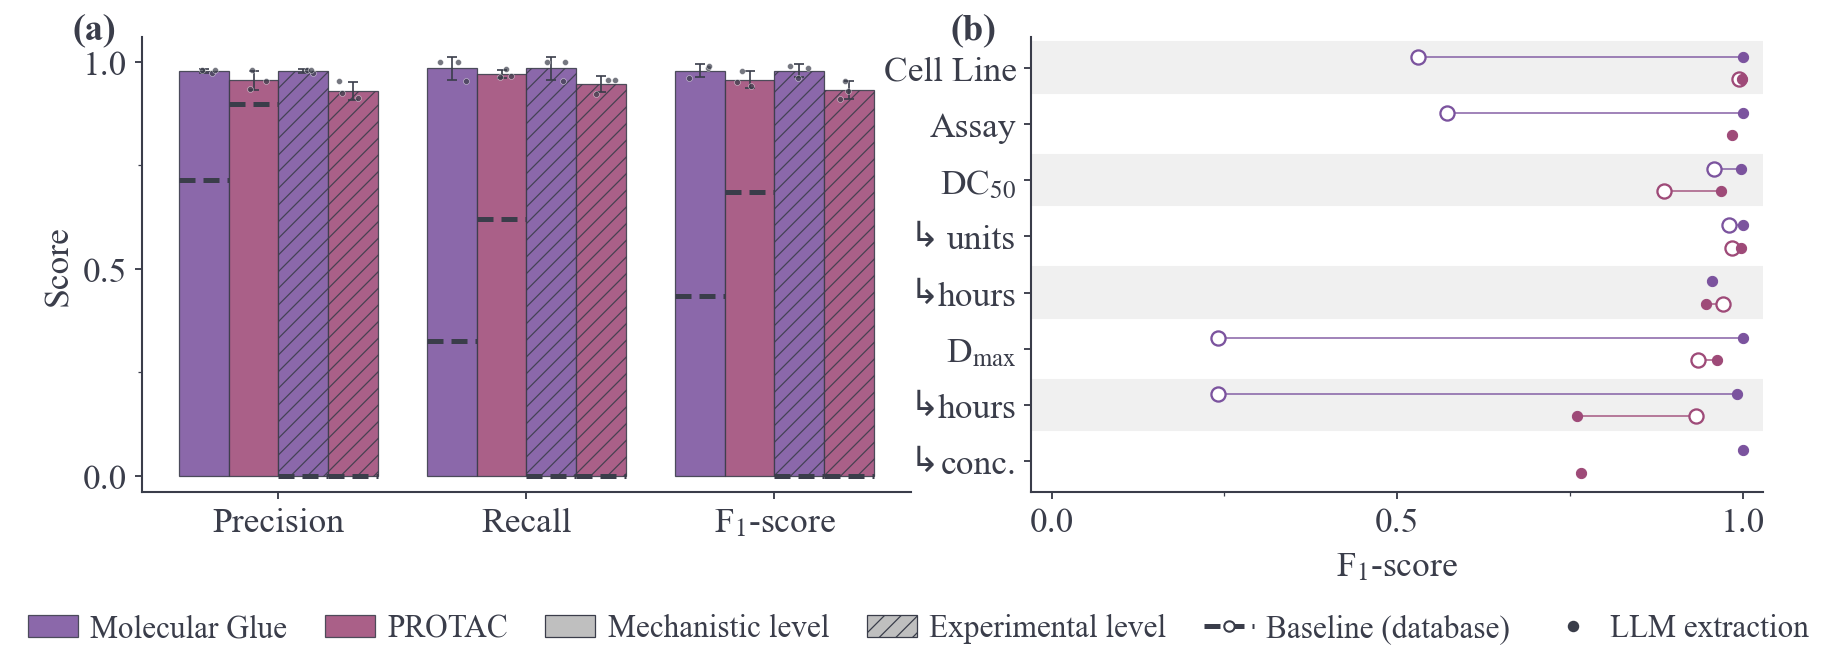

In [7]:
TIMES_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
}

with plt.rc_context(TIMES_RC):
    fig = plt.figure(figsize=(11.5, 4.6))
    gs  = fig.add_gridspec(
        1, 2, width_ratios=[1.05, 1.0],
        left=0.05, right=0.99, top=0.93, bottom=0.27, wspace=0.16,
    )
    ax_a = fig.add_subplot(gs[0])
    ax_b = fig.add_subplot(gs[1])

    TICK_FS   = 17
    LABEL_FS  = 17
    PANEL_FS  = 18
    LEGEND_FS = 15
    BASELINE_LW    = 2.4
    BASELINE_DASH  = (0, (3.2, 1.6))   

    metric_labels = ["Precision", "Recall", r"F$_1$-score"]
    x = np.arange(len(metric_labels))
    bar_w = 0.20
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_w  

    bar_specs = [
        (mg_mech_arr,     mg_bl_mech,     ROYAL_PURPLE, None,  offsets[0]),
        (protac_mech_arr, protac_bl_mech, MUTED_PLUM,   None,  offsets[1]),
        (mg_exp_arr,      mg_bl_exp,      ROYAL_PURPLE, "///", offsets[2]),
        (protac_exp_arr,  protac_bl_exp,  MUTED_PLUM,   "///", offsets[3]),
    ]

    rng = np.random.default_rng(42)

    for llm_mat, bl_vals, color, hatch, off in bar_specs:
        bar_x = x + off
        means = llm_mat.mean(axis=1)
        sds   = llm_mat.std(axis=1, ddof=1)
        ax_a.bar(bar_x, means, width=bar_w, color=color, alpha=0.88,
                 edgecolor=DARK_SLATE, linewidth=0.6, hatch=hatch, zorder=2)
        ax_a.errorbar(bar_x, means, yerr=sds, fmt="none", color=DARK_SLATE,
                      linewidth=0.8, capsize=2.2, capthick=0.8, zorder=4)
        for j, col_vals in enumerate(llm_mat):
            jitter = rng.uniform(-bar_w * 0.30, bar_w * 0.30, size=len(col_vals))
            ax_a.scatter(bar_x[j] + jitter, col_vals, s=8, color=DARK_SLATE,
                         alpha=0.7, linewidths=0.25, edgecolors="white", zorder=5)
        for j, bv in enumerate(bl_vals):
            ax_a.plot([bar_x[j] - bar_w / 2, bar_x[j] + bar_w / 2], [bv, bv],
                      color=DARK_SLATE, linestyle=BASELINE_DASH, lw=BASELINE_LW,
                      solid_capstyle="butt", zorder=6)

    ax_a.set_xticks(x)
    ax_a.set_xticklabels(metric_labels, fontsize=TICK_FS)
    ax_a.set_ylim(-0.04, 1.06)
    ax_a.set_yticks([0.0, 0.5, 1.0])
    ax_a.yaxis.set_minor_locator(MultipleLocator(0.25))
    ax_a.tick_params(axis="x", labelsize=TICK_FS)
    ax_a.tick_params(axis="y", labelsize=TICK_FS)
    ax_a.tick_params(which="minor", length=2.0, width=0.6, direction="out")
    ax_a.set_ylabel("Score", fontsize=LABEL_FS)
    ax_a.set_xlim(-0.55, len(metric_labels) - 0.45)
    ax_a.spines["top"].set_visible(False)
    ax_a.spines["right"].set_visible(False)
    ax_a.spines["bottom"].set_position(("data", -0.04))
    ax_a.text(-0.09, 1.05, "(a)", transform=ax_a.transAxes,
              fontsize=PANEL_FS, fontweight="bold", va="top", ha="left",
              color=DARK_SLATE)

    FIELD_LABELS_SHORT = {
        "Cell_Line":  "Cell Line",
        "Assay":      "Assay",
        "DC50":       r"DC$_{50}$",
        "DC50_units": "units",
        "DC50_h":     "hours",
        "Dmax":       r"D$_{\max}$",
        "Dmax_h":     "hours",
        "Dmax_conc":  "conc.",
    }
    field_labels_b = [FIELD_LABELS_SHORT[f] for f in FIELDS]

    y_positions   = np.arange(len(FIELDS))[::-1]
    DOMAIN_OFFSET = {"MG": +0.20, "PROTAC": -0.20}
    DOMAIN_COLOR  = {"MG": ROYAL_PURPLE, "PROTAC": MUTED_PLUM}
    DOMAIN_DATA   = {
        "MG":     (mg_bl_field_f1,     mg_field_f1),
        "PROTAC": (protac_bl_field_f1, protac_field_f1),
    }
    for idx, field in enumerate(FIELDS):
        if idx % 2 == 0:
            ax_b.axhspan(y_positions[idx] - 0.45, y_positions[idx] + 0.45,
                         color="#F0F0F0", zorder=0)

    for idx, field in enumerate(FIELDS):
        y_base = y_positions[idx]
        for domain in ("MG", "PROTAC"):
            y     = y_base + DOMAIN_OFFSET[domain]
            color = DOMAIN_COLOR[domain]
            bl_dict, llm_dict = DOMAIN_DATA[domain]
            bl_v  = bl_dict.get(field, np.nan)
            llm_v = llm_dict.get(field, np.nan)
            if not np.isnan(bl_v) and not np.isnan(llm_v):
                ax_b.plot([bl_v, llm_v], [y, y], color=color, lw=0.9,
                          alpha=0.75, zorder=2)
            if not np.isnan(bl_v):
                ax_b.scatter(bl_v, y, s=46, facecolors="white",
                             edgecolors=color, linewidths=1.1, zorder=4,
                             marker="o")
            if not np.isnan(llm_v):
                ax_b.scatter(llm_v, y, s=24, facecolors=color,
                             edgecolors=color, linewidths=0.5, zorder=5,
                             marker="o")

    ax_b.set_yticks(y_positions)
    ax_b.set_yticklabels(field_labels_b, fontsize=TICK_FS)

    CHILD_FIELDS = {"DC50_units", "DC50_h", "Dmax_h", "Dmax_conc"}

    for idx, field in enumerate(FIELDS):
        if field in CHILD_FIELDS:
            ax_b.text(
                -0.125, y_positions[idx], "↳",
                transform=ax_b.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=TICK_FS,
                fontfamily="DejaVu Sans",
                color=DARK_SLATE,
                clip_on=False,
            )
    ax_b.set_ylim(y_positions[-1] - 0.55, y_positions[0] + 0.55)
    ax_b.set_xlim(-0.03, 1.03)
    ax_b.set_xlabel(r"F$_1$-score", fontsize=LABEL_FS, labelpad=6)
    ax_b.tick_params(axis="x", labelsize=TICK_FS)
    ax_b.tick_params(axis="y", labelsize=TICK_FS)
    ax_b.xaxis.set_major_locator(MultipleLocator(0.5))
    ax_b.xaxis.set_minor_locator(MultipleLocator(0.25))
    ax_b.tick_params(which="minor", length=2.0, width=0.6, direction="out")
    ax_b.spines["top"].set_visible(False)
    ax_b.spines["right"].set_visible(False)
    ax_b.text(-0.11, 1.05, "(b)", transform=ax_b.transAxes,
              fontsize=PANEL_FS, fontweight="bold", va="top", ha="left",
              color=DARK_SLATE)
    NEUTRAL = "#BFBFBF"

    legend_handles = [
        mpatches.Patch(facecolor=ROYAL_PURPLE, edgecolor=DARK_SLATE, alpha=0.88,
                       linewidth=0.6, label="Molecular Glue"),
        mpatches.Patch(facecolor=MUTED_PLUM, edgecolor=DARK_SLATE, alpha=0.88,
                       linewidth=0.6, label="PROTAC"),
        mpatches.Patch(facecolor=NEUTRAL, edgecolor=DARK_SLATE, linewidth=0.6,
                       label="Mechanistic level"),
        mpatches.Patch(facecolor=NEUTRAL, edgecolor=DARK_SLATE, linewidth=0.6,
                       hatch="///", label="Experimental level"),
        mlines.Line2D([], [], color=DARK_SLATE, linestyle=BASELINE_DASH,
                      lw=BASELINE_LW,
                      marker="o", markerfacecolor="white",
                      markeredgecolor=DARK_SLATE, markersize=5,
                      label="Baseline (database)"),
        mlines.Line2D([], [], color=DARK_SLATE, lw=0,
                      marker="o", markerfacecolor=DARK_SLATE,
                      markersize=4.5, label="LLM extraction"),
    ]

    fig.legend(handles=legend_handles,
               loc="lower center", bbox_to_anchor=(0.5, 0.01),
               ncol=6, frameon=False, fontsize=LEGEND_FS,
               columnspacing=1.2, handletextpad=0.4, handlelength=1.6)

    fig_dir = Path("figures")
    fig_dir.mkdir(exist_ok=True)
    fig.savefig(fig_dir / "llm-baseline-vs-gt.png")
    fig.savefig(fig_dir / "llm-baseline-vs-gt.pdf")
    plt.show()